# <u> **Conference Calls Stakeholder Engagement or Orientation NLP Analysis** </u>

### **Data Analysis Steps:**
- Obtain transcripts from platforms like Seeking Alpha or company investor relations pages.
- Preprocess transcripts to correct speech-to-text errors and segment by speaker.
- Apply KeyBERT to extract stakeholder keywords (e.g., “customer satisfaction,” “supplier partnerships”).
- Use sentiment analysis to evaluate the tone of stakeholder discussions.
- Train a classifier (e.g., XGBoost) to categorize engagement by stakeholder group (e.g., employees, customers).

### **Challenges:**
- Transcript errors from automated speech recognition can distort results.
- Brief mentions of stakeholders limit data depth.
- Non-verbal cues (e.g., tone of voice) are unavailable in text.

### **Example:**
- In a conference call, a CFO might say: “We’re investing heavily in customer experience to drive loyalty.” NLP can extract “customer experience” and “loyalty,” classify the tone as positive, and flag it as a customer-oriented signal.

### **About the Data used:**
- https://www.marketbeat.com/earnings/reports/2026-8-27-the-toronto-dominion-bank-stock/#transcript
- Toronto Dominion Bank (TD) Q3 2026 Earnings Report.
- Quarter: Q3 2026.
- Date: 8/27/2026.
- Time: Before Market Opens.
- Conference Call Date: Thursday, August 27, 2026.
- Conference Call Time: 9:30AM ET.

---

## **Importing Packages:**

In [82]:
from MyPackages import *


---

## **Obtain transcripts from platforms like Seeking Alpha or company investor relations pages:**

In [83]:
speechlst = []

soup = web_text(url= 'https://www.marketbeat.com/earnings/reports/2026-8-27-the-toronto-dominion-bank-stock/#transcript')

for i in soup.find_all('p'):
    speechlst.append(i.get_text(strip= True))

for i in range(len(speechlst)):
    print(i, ' - ', speechlst[i])

0  -  Good morning, everyone. Welcome to the TD Bank Group third quarter 2026 earnings conference call. I would now like to turn the meeting over to Ms. Brooke Hales, Head of Investor Relations. Please go ahead, Ms. Hales.
1  -  Thank you, operator. Good morning, and welcome to TD Bank Group's third quarter 2026 results presentation. We will begin today's presentation with remarks from Raymond Chun, the bank's CEO, followed by Leo Salom, Group Head, U.S. Banking, after which Kelvin Tran, the bank's CFO, will present our third quarter operating results. Ajai Bambawale, Chief Risk Officer, will then offer comments on credit quality, after which we will invite questions from analysts on the phone. Also present today to answer your questions are Sona Mehta, Group Head, Canadian Personal Banking, Barbara Hooper, Group Head, Canadian Business Banking, Paul Clark, Group Head, Wealth Management and Insurance, and Tim Wiggan, Group Head, Wholesale Banking. Please turn to the next slide. Our com

> This is the text from the transcript of all the speech. It is the lines of text of what everyone said during the earnings report conference call.

In [84]:
df_speech = {'speech': speechlst}
df_speech = pd.DataFrame(df_speech)

> The list containing all the speech has then been converted into a dataframe format. This allows for easier access of the data to modify and analyze.

In [85]:
timelst = []

soup = web_text(url= 'https://www.marketbeat.com/earnings/reports/2026-8-27-the-toronto-dominion-bank-stock/#transcript')

for i in soup.find_all('time'):
    timelst.append(i.get_text(strip= True))

for i in range(len(timelst)):
    print(i, ' - ', timelst[i])

0  -  00:00:00
1  -  00:00:12
2  -  00:01:08
3  -  00:01:38
4  -  00:02:27
5  -  00:03:32
6  -  00:04:48
7  -  00:05:45
8  -  00:06:45
9  -  00:07:43
10  -  00:08:47
11  -  00:09:52
12  -  00:10:59
13  -  00:12:06
14  -  00:13:03
15  -  00:14:05
16  -  00:15:10
17  -  00:15:13
18  -  00:16:09
19  -  00:17:10
20  -  00:18:21
21  -  00:19:42
22  -  00:20:53
23  -  00:22:11
24  -  00:23:26
25  -  00:24:37
26  -  00:25:07
27  -  00:26:30
28  -  00:27:59
29  -  00:29:08
30  -  00:29:36
31  -  00:29:57
32  -  00:30:15
33  -  00:31:01
34  -  00:31:28
35  -  00:31:35
36  -  00:31:51
37  -  00:31:53
38  -  00:31:55
39  -  00:32:00
40  -  00:32:29
41  -  00:33:11
42  -  00:34:01
43  -  00:34:38
44  -  00:35:33
45  -  00:36:25
46  -  00:36:48
47  -  00:37:42
48  -  00:38:33
49  -  00:39:31
50  -  00:39:36
51  -  00:39:43
52  -  00:40:23
53  -  00:40:29
54  -  00:40:36
55  -  00:40:36
56  -  00:40:38
57  -  00:41:04
58  -  00:41:53
59  -  00:42:31
60  -  00:42:57
61  -  00:43:41
62  -  00:43:42
63

> A new list has been created storing the time of eachtime a new person spoke during the meeting. It is the time for each line of text in the speech dataframe.

In [86]:
df_time = {'time': timelst}
df_time = pd.DataFrame(df_time)

> A time dataframe has been created to store the content of the time list.

In [87]:
sectionlst = []

soup = web_text(url= 'https://www.marketbeat.com/earnings/reports/2026-8-27-the-toronto-dominion-bank-stock/#transcript')

for i in soup.find_all('section'):
    sectionlst.append(i.get_text(strip= True))

for i in range(len(sectionlst)):
    print(i, ' - ', sectionlst[i])

0  -  Operator00:00:00Good morning, everyone. Welcome to the TD Bank Group third quarter 2026 earnings conference call. I would now like to turn the meeting over to Ms. Brooke Hales, Head of Investor Relations. Please go ahead, Ms. Hales.
1  -  Brooke HalesHead of Investor Relations at TD Bank Group00:00:12Thank you, operator. Good morning, and welcome to TD Bank Group's third quarter 2026 results presentation. We will begin today's presentation with remarks from Raymond Chun, the bank's CEO, followed by Leo Salom, Group Head, U.S. Banking, after which Kelvin Tran, the bank's CFO, will present our third quarter operating results. Ajai Bambawale, Chief Risk Officer, will then offer comments on credit quality, after which we will invite questions from analysts on the phone. Also present today to answer your questions are Sona Mehta, Group Head, Canadian Personal Banking, Barbara Hooper, Group Head, Canadian Business Banking, Paul Clark, Group Head, Wealth Management and Insurance, and Ti

> This list shows all the data from each section of the transcript. The section in the html refers to each time someone spoke. The section includes data on who exactly spoke, at what time did they speak, and what speech that person spoke. This data will be used to get the names and positions of each person who spoke each line of text.

## **Preprocess transcripts to correct speech-to-text errors and segment by speaker:**

In [88]:
df_speech = df_speech[df_speech['speech'].index <= 95]

> When parsing the speech text from the html web page, it got text which should not belong in the dataframe. Some of the text at the end of the page is labeled as "p" as in "paragraph", which is what the speech text is labeled as. So, this extra text must be removed.

In [89]:
df_time['time'] = pd.to_datetime(df_time['time'], format= '%H:%M:%S').dt.time

> The timestamps of each text is converted into a datetime data type format. The format is in Hours, Minutes, Seconds.

In [90]:
for i in range(len(sectionlst)):
    sectionlst[i] = sectionlst[i].replace(speechlst[i], '')
    sectionlst[i] = sectionlst[i].replace(timelst[i], '')

df_speaker = {'speaker': sectionlst}
df_speaker = pd.DataFrame(df_speaker)

> The speech text and the time stamps have been remove from the sections list. Now all that is left are the speaker names and their positions in TD Bank. The speaker dataframe has been created.

In [91]:
df_speech = df_speech.reset_index()
df_speech = df_speech.drop(labels= 'index', axis= 1)

df_time = df_time.reset_index()
df_time = df_time.drop(labels= 'index', axis= 1)

df_speaker = df_speaker.reset_index()
df_speaker = df_speaker.drop(labels= 'index', axis= 1)

> The indices have been reset for all dataframes.

In [92]:
df = pd.merge(df_speaker, df_time, left_index= True, right_index= True)
df = pd.merge(df, df_speech, left_index= True, right_index= True)
df

,speaker,time,speech
0,Operator,00:00:00,"Good morning, everyone. Welcome to the TD Bank..."
1,Brooke HalesHead of Investor Relations at TD B...,00:00:12,"Thank you, operator. Good morning, and welcome..."
2,Brooke HalesHead of Investor Relations at TD B...,00:01:08,I would also remind listeners that the bank us...
3,Raymond ChunCEO at TD Bank Group,00:01:38,"Thank you, Brooke, and good morning, everyone...."
4,Raymond ChunCEO at TD Bank Group,00:02:27,"In a report published earlier this week, TD Ec..."
...,...,...,...
91,Paul HoldenAnalyst at CIBC,00:56:10,"Very helpful. Again, actually very impressive ..."
92,Raymond ChunCEO at TD Bank Group,00:56:19,"Thanks, Paul."
93,Operator,00:56:22,Thank you. There are no more questions in the ...
94,Raymond ChunCEO at TD Bank Group,00:56:31,"Thank you, operator, and thank you everyone fo..."


> The complete dataframe which contains all the data has been completed. The dataframe contains data on who is speaking, what time did they start speaking at, and what speech they gave during the earnings report conference call.

In [93]:
df = df[df['speech'].str.len() >= 90]

df = df.reset_index()
df = df.drop(labels= 'index', axis= 1)

> The last step that must be done is to remove unimportant and unnecessary text from the speech column. This includes lines of text that are greetings ("Hello, the meeting will start now!"), farewells ("Have a nice day everyone, Goodbye!"), and one word lines of text ("Yeah.", "Thats right.", or "Go ahead."). These lines of text hold no value and will not contribute anything to the overall analysis results, and they only add noise.

## **Apply KeyBERT to extract stakeholder keywords (e.g., “customer satisfaction,” “supplier partnerships”):**

In [94]:
model = KeyBERT()
keywords = model.extract_keywords(df['speech'].tolist())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

> The KeyBERT model has been used to get 5 keywords for each line of speech text. These keywords are used to summarize each line of text. The first keyword is the most important and represents the text the best out of all 5 keywords.

In [95]:
keyword0 = []
keyword1 = []
keyword2 = []
keyword3 = []
keyword4 = []

for i in range(len(keywords)):
    keyword0.append(keywords[i][0][0])
    keyword1.append(keywords[i][1][0])
    keyword2.append(keywords[i][2][0])
    keyword3.append(keywords[i][3][0])
    keyword4.append(keywords[i][4][0])

keywords = {
    'keyword0': keyword0,
    'keyword1': keyword1,
    'keyword2': keyword2,
    'keyword3': keyword3,
    'keyword4': keyword4
}

keywords = pd.DataFrame(keywords)
keywords

,keyword0,keyword1,keyword2,keyword3,keyword4
0,meeting,conference,hales,earnings,bank
1,banking,bank,cfo,analysts,credit
2,gaap,adjusted,bank,financial,performance
3,canadian,canada,investment,banking,economies
4,banking,investment,earnings,cad,fiscal
...,...,...,...,...,...
71,leverage,investments,expense,bank,efficiency
72,growth,store,expense,helpful,grow
73,queue,closing,chun,questions,return
74,earnings,roe,q3,td,stakeholders


> The keywords for each line of text have been organized neatly into a dataframe. These columns of keywords, organized from most important keyword to least important, will be added to the overall dataframe.

In [96]:
df = pd.merge(df, keywords, left_index= True, right_index= True)
df

,speaker,time,speech,keyword0,keyword1,keyword2,keyword3,keyword4
0,Operator,00:00:00,"Good morning, everyone. Welcome to the TD Bank...",meeting,conference,hales,earnings,bank
1,Brooke HalesHead of Investor Relations at TD B...,00:00:12,"Thank you, operator. Good morning, and welcome...",banking,bank,cfo,analysts,credit
2,Brooke HalesHead of Investor Relations at TD B...,00:01:08,I would also remind listeners that the bank us...,gaap,adjusted,bank,financial,performance
3,Raymond ChunCEO at TD Bank Group,00:01:38,"Thank you, Brooke, and good morning, everyone....",canadian,canada,investment,banking,economies
4,Raymond ChunCEO at TD Bank Group,00:02:27,"In a report published earlier this week, TD Ec...",banking,investment,earnings,cad,fiscal
...,...,...,...,...,...,...,...,...
71,Raymond ChunCEO at TD Bank Group,00:55:56,It is an area of focus for every single leader...,leverage,investments,expense,bank,efficiency
72,Paul HoldenAnalyst at CIBC,00:56:10,"Very helpful. Again, actually very impressive ...",growth,store,expense,helpful,grow
73,Operator,00:56:22,Thank you. There are no more questions in the ...,queue,closing,chun,questions,return
74,Raymond ChunCEO at TD Bank Group,00:56:31,"Thank you, operator, and thank you everyone fo...",earnings,roe,q3,td,stakeholders


> The keywords for each line of text have been merged with the dataframe and now it is visible which keywords come from which line of text. This dataframe is ready for analysis, and extract of stakeholder related keywords can be done.

In [97]:
counts = df['keyword0'].value_counts().reset_index().head(10)
counts

,keyword0,count
0,banking,14
1,bank,3
2,capital,3
3,buybacks,3
4,earnings,2
5,loan,2
6,reinvestment,2
7,cet1,2
8,leverage,2
9,canadian,1


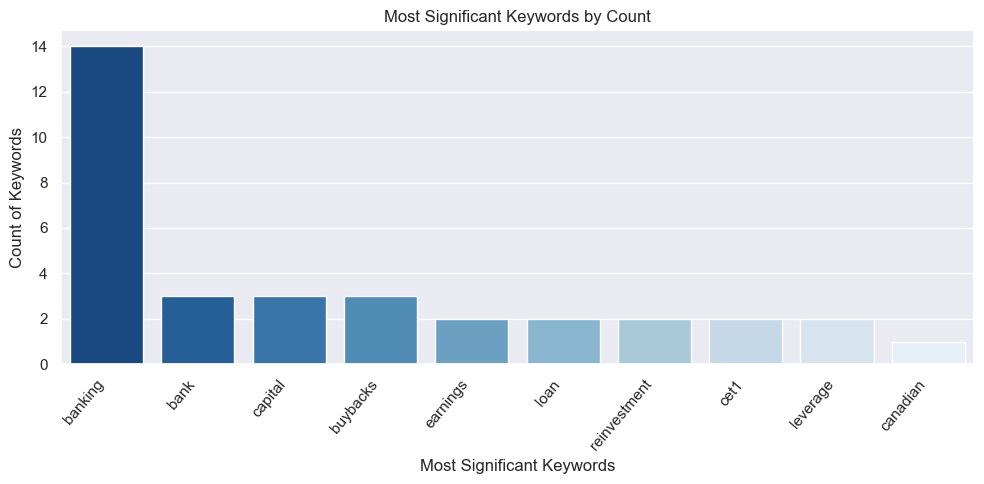

In [98]:
sns.set_theme('notebook')
plt.figure(figsize= (10, 5))

sns.barplot(x= counts['keyword0'], y= counts['count'], palette= 'Blues_r')
plt.title('Most Significant Keywords by Count')
plt.ylabel('Count of Keywords')
plt.xlabel('Most Significant Keywords')
plt.xticks(rotation= 50, ha= 'right')

plt.tight_layout()
plt.show()

> This is a quick analysis for all keywords. The first column of keywords (keyword0) are the most significant keywords which best explain the given lines of text. The most frequent keyword of these is banking, at a count of 14. This means that 14 of the 76 lines of text from the TD Bank conference call script can be summarized best by the word "banking". The second most frequent words are bank, capital, and buy backs, which all have a count of 3.

In [99]:
stakeholder_keywords = [
    'stakeholder',
    'stakeholders',
    'stakeholder interests',
    'stakeholder needs',
    'stakeholder expectations',
    'stakeholder concerns',
    'stakeholder relations',
    'stakeholder engagement',
    'stakeholder communication',
    'stakeholder dialogue',
    'stakeholder value',
    'stakeholder priorities',
    'stakeholder perspectives',
    'stakeholder groups',
    'customer',
    'customers',
    'customer satisfaction',
    'customer experience',
    'customer needs',
    'customer expectations',
    'customer relationships',
    'customer relations',
    'customer engagement',
    'customer feedback',
    'customer loyalty',
    'customer retention',
    'customer service',
    'customer support',
    'consumer',
    'consumers',
    'consumer satisfaction',
    'consumer needs',
    'consumer expectations',
    'consumer engagement',
    'supplier',
    'suppliers',
    'supplier relationships',
    'supplier partnerships',
    'supplier engagement',
    'supplier relations',
    'supplier management',
    'supplier diversity',
    'supplier performance',
    'supplier expectations',
    'supplier requirements',
    'supplier collaboration',
    'vendor',
    'vendors',
    'vendor relationships',
    'vendor management',
    'business partners',
    'business partnership',
    'strategic partners',
    'strategic partnership',
    'employee',
    'employees',
    'employee engagement',
    'employee satisfaction',
    'employee relations',
    'employee well-being',
    'employee wellbeing',
    'employee experience',
    'employee retention',
    'employee development',
    'employee needs',
    'employee concerns',
    'employee feedback',
    'workforce',
    'workforce engagement',
    'workforce development',
    'talent',
    'talent development',
    'human capital',
    'human capital management',
    'investor',
    'investors',
    'investor relations',
    'investor engagement',
    'investor communication',
    'investor expectations',
    'investor concerns',
    'shareholder',
    'shareholders',
    'shareholder engagement',
    'shareholder relations',
    'shareholder interests',
    'shareholder concerns',
    'shareholder expectations',
    'shareholder value',
    'shareholder communication',
    'stockholder',
    'stockholders',
    'stockholder interests',
    'community',
    'communities',
    'community engagement',
    'community relations',
    'community investment',
    'community development',
    'community needs',
    'community interests',
    'local community',
    'local communities',
    'social impact',
    'social responsibility',
    'societal impact',
    'public interest',
    'regulator',
    'regulators',
    'regulatory authorities',
    'government agencies',
    'government relations',
    'regulatory engagement',
    'regulatory stakeholders',
    'public authorities',
    'policymakers',
    'policy makers',
    'government officials',
    'engagement',
    'engagement strategy',
    'stakeholder engagement',
    'relationship',
    'relationships',
    'partnership',
    'partnerships',
    'collaboration',
    'collaborations',
    'dialogue',
    'consultation',
    'consultations',
    'communication',
    'communications',
    'feedback',
    'listening',
    'outreach',
    'participation',
    'involvement',
    'concerns',
    'stakeholder concerns',
    'needs',
    'expectations',
    'interests',
    'priorities',
    'preferences',
    'feedback',
    'requests',
    'recommendations',
    'issues',
    'grievances',
    'complaints',
    'stakeholder value',
    'shared value',
    'long-term value',
    'social value',
    'corporate responsibility',
    'corporate citizenship',
    'responsible business',
    'sustainable value',
    'shared interests',
    'mutual interests',
    'mutual benefit'
]

> These are the keywords that will be searched for and extracted from the keywords of the dataframe.
>
> NOTE: This list was generated by ChatGPT.

In [100]:
stakeholder = df[df['keyword0'].isin(stakeholder_keywords) | df['keyword1'].isin(stakeholder_keywords) | df['keyword2'].isin(stakeholder_keywords) | df['keyword3'].isin(stakeholder_keywords) | df['keyword4'].isin(stakeholder_keywords)]
stakeholder

,speaker,time,speech,keyword0,keyword1,keyword2,keyword3,keyword4
8,Raymond ChunCEO at TD Bank Group,00:06:45,We delivered strong performance in our busines...,banking,bank,lending,loans,investor
9,Raymond ChunCEO at TD Bank Group,00:07:43,Consistent with the branch repositioning plan ...,invest,investing,etfs,investor,assets
12,Raymond ChunCEO at TD Bank Group,00:10:59,We are also leveraging AI to enhance the colle...,finance,banking,bank,funding,investor
31,Leo SalomGroup Head of U.S. Banking at TD Bank...,00:30:15,"Just by way of context, that is very consisten...",reinvestment,consolidate,aml,msas,investor
36,Raymond ChunCEO at TD Bank Group,00:32:29,"Thanks for the question, Gabe, and good mornin...",capital,investment,growth,organic,investor
37,Raymond ChunCEO at TD Bank Group,00:33:11,"Then we sort of say, are there opportunities t...",capital,shareholders,opportunities,investor,securities
38,Raymond ChunCEO at TD Bank Group,00:34:01,"All that to say, I think we're in an incredibl...",wholesale,shareholders,acquisition,business,growth
45,Doug YoungAnalyst at Desjardins,00:39:43,"Hi, good morning. I was distracted, Ray, throu...",buybacks,dividend,shareholders,return,valuations
46,Doug YoungAnalyst at Desjardins,00:40:38,"Yeah. Sorry. Not sure what's going on. No, I j...",buybacks,shareholders,dividends,growth,capital
48,Raymond ChunCEO at TD Bank Group,00:41:53,"As you have seen in our results, when we conti...",momentum,q4,upside,investor,adjustments


> These are the records from the dataframe that have been identified to contain keywords (from each of the keyword columns) that are stakeholder related.

In [101]:
stakeholder['speech'].tolist()

['We delivered strong performance in our business bank with loans and non-term deposits each up 8% year-over-year and commercial client acquisition up 10% year-to-date, reflecting the benefits of our distribution expansion. This quarter marked an important inflection point for our U.S. Banking segment, with total loans positive sequentially. The team continued to execute against the organic growth strategies we laid out at Investor Day. U.S. bank card balances, mid-market lending, and home equity lending were up 20%, 15%, and 6% year-over-year respectively. In our U.S. wealth business, we delivered record mass affluent investment assets driven by net asset growth and market appreciation. As we look ahead, branch expansion remains an important component of our growth strategy in the U.S.',
 'Consistent with the branch repositioning plan shared at Investor Day and subject to regulatory approval, we are focused on opening 100 new branches by the end of calendar 2028, with work ongoing to 

> These are the lines of text which are represented by stakeholder related keywords.

In [102]:
words = pd.concat([stakeholder['keyword0'], stakeholder['keyword1'], stakeholder['keyword2'], stakeholder['keyword3'], stakeholder['keyword4']])

words = words.reset_index()
words = words.drop(labels= 'index', axis= 1)

words['keywords'] = words[0]
words = words.drop(labels= 0, axis= 1)

> Each of the stakeholder keywords have been concatenated. The goal with this is to count them and graph them. Also the index has been reset, and the column which contains the keywords has been renamed.

In [103]:
counts = words['keywords'].value_counts().head(10).reset_index()
counts

,keywords,count
0,investor,8
1,shareholders,4
2,banking,3
3,growth,3
4,capital,3
5,bank,2
6,buybacks,2
7,wholesale,1
8,invest,1
9,finance,1


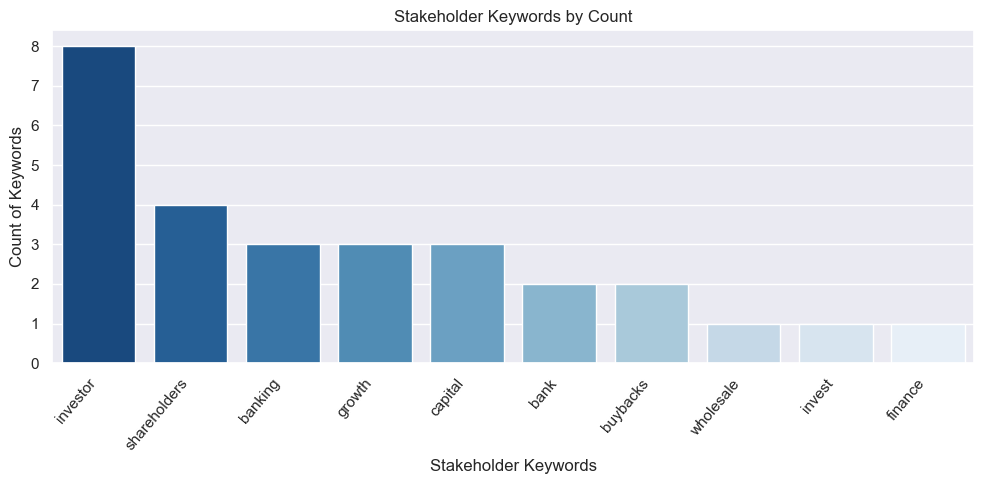

In [104]:
sns.set_theme('notebook')
plt.figure(figsize= (10, 5))

sns.barplot(x= counts['keywords'], y= counts['count'], palette= 'Blues_r')
plt.title('Stakeholder Keywords by Count')
plt.ylabel('Count of Keywords')
plt.xlabel('Stakeholder Keywords')
plt.xticks(rotation= 50, ha= 'right')

plt.tight_layout()
plt.show()

> As represented by the chart and the table above, the most frequent stakeholder related keyword that best represents the text is investor, at a count of 8 references. Second are the stakeholder keywords shareholder and growth, which are both at a count of 4. Third are capital and banking, which are both less commonly stakeholder related keywords, but they show up a total of 3 times each.

## **Use sentiment analysis to evaluate the tone of stakeholder discussions:**

In [105]:
stakeholder = stakeholder.reset_index()
stakeholder = stakeholder.drop(labels= 'index', axis= 1)
stakeholder

,speaker,time,speech,keyword0,keyword1,keyword2,keyword3,keyword4
0,Raymond ChunCEO at TD Bank Group,00:06:45,We delivered strong performance in our busines...,banking,bank,lending,loans,investor
1,Raymond ChunCEO at TD Bank Group,00:07:43,Consistent with the branch repositioning plan ...,invest,investing,etfs,investor,assets
2,Raymond ChunCEO at TD Bank Group,00:10:59,We are also leveraging AI to enhance the colle...,finance,banking,bank,funding,investor
3,Leo SalomGroup Head of U.S. Banking at TD Bank...,00:30:15,"Just by way of context, that is very consisten...",reinvestment,consolidate,aml,msas,investor
4,Raymond ChunCEO at TD Bank Group,00:32:29,"Thanks for the question, Gabe, and good mornin...",capital,investment,growth,organic,investor
5,Raymond ChunCEO at TD Bank Group,00:33:11,"Then we sort of say, are there opportunities t...",capital,shareholders,opportunities,investor,securities
6,Raymond ChunCEO at TD Bank Group,00:34:01,"All that to say, I think we're in an incredibl...",wholesale,shareholders,acquisition,business,growth
7,Doug YoungAnalyst at Desjardins,00:39:43,"Hi, good morning. I was distracted, Ray, throu...",buybacks,dividend,shareholders,return,valuations
8,Doug YoungAnalyst at Desjardins,00:40:38,"Yeah. Sorry. Not sure what's going on. No, I j...",buybacks,shareholders,dividends,growth,capital
9,Raymond ChunCEO at TD Bank Group,00:41:53,"As you have seen in our results, when we conti...",momentum,q4,upside,investor,adjustments


> For this analysis, the dataframe labelled as stakeholder will be used. This is because it contains all lines of text in the dataframe that are considered stakeholder discussions. Each line of text is represented by a keyword that is related to stakeholder language.

In [106]:
finbertOutput = finbert(stakeholder['speech'].tolist())
finbertOutput = pd.DataFrame(finbertOutput)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

> This is the finbert output. It must be added to the dtakeholder dataframe.

In [107]:
stakeholder = pd.merge(stakeholder, finbertOutput, left_index= True, right_index= True)
stakeholder

,speaker,time,speech,keyword0,keyword1,keyword2,keyword3,keyword4,label,score
0,Raymond ChunCEO at TD Bank Group,00:06:45,We delivered strong performance in our busines...,banking,bank,lending,loans,investor,positive,0.954413
1,Raymond ChunCEO at TD Bank Group,00:07:43,Consistent with the branch repositioning plan ...,invest,investing,etfs,investor,assets,positive,0.945341
2,Raymond ChunCEO at TD Bank Group,00:10:59,We are also leveraging AI to enhance the colle...,finance,banking,bank,funding,investor,positive,0.946477
3,Leo SalomGroup Head of U.S. Banking at TD Bank...,00:30:15,"Just by way of context, that is very consisten...",reinvestment,consolidate,aml,msas,investor,positive,0.886954
4,Raymond ChunCEO at TD Bank Group,00:32:29,"Thanks for the question, Gabe, and good mornin...",capital,investment,growth,organic,investor,neutral,0.764357
5,Raymond ChunCEO at TD Bank Group,00:33:11,"Then we sort of say, are there opportunities t...",capital,shareholders,opportunities,investor,securities,neutral,0.857169
6,Raymond ChunCEO at TD Bank Group,00:34:01,"All that to say, I think we're in an incredibl...",wholesale,shareholders,acquisition,business,growth,neutral,0.814827
7,Doug YoungAnalyst at Desjardins,00:39:43,"Hi, good morning. I was distracted, Ray, throu...",buybacks,dividend,shareholders,return,valuations,neutral,0.641179
8,Doug YoungAnalyst at Desjardins,00:40:38,"Yeah. Sorry. Not sure what's going on. No, I j...",buybacks,shareholders,dividends,growth,capital,neutral,0.920291
9,Raymond ChunCEO at TD Bank Group,00:41:53,"As you have seen in our results, when we conti...",momentum,q4,upside,investor,adjustments,positive,0.632611


> This is the complete dataframe. It shows the lines of speech text by individual speakers which are labeled by stakeholder related keywords. It now also shows the sentiment for each line of text.

In [108]:
counts = stakeholder['label'].value_counts().reset_index()
counts

,label,count
0,positive,7
1,neutral,5


In [109]:
stakeholder['label'].value_counts(normalize= True).reset_index()

,label,proportion
0,positive,0.583333
1,neutral,0.416667


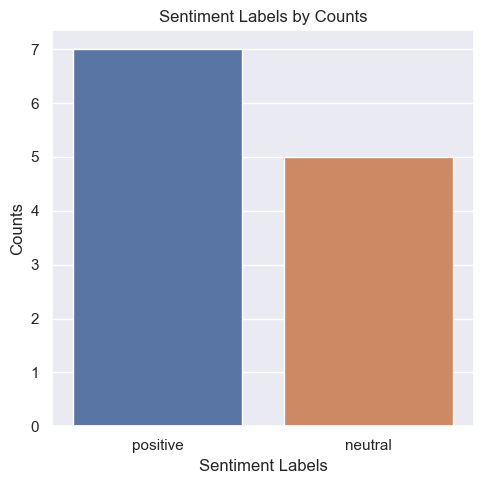

In [110]:
sns.set_theme('notebook')
plt.figure(figsize= (5, 5))

sns.barplot(x= counts['label'], y= counts['count'], hue= counts['label'])
plt.title('Sentiment Labels by Counts')
plt.ylabel('Counts')
plt.xlabel('Sentiment Labels')

plt.tight_layout()
plt.show()

> It can see from the graphical representation, as well as from the two tables above that 7 of the 12 stakeholder related lines of text from the conference call by TD bank are labeled as positive sentiment. The other 6 lines of stakeholder speech are neutral. There are no stakeholder related lines of text that are labelled as negative by the FinBERT model. They are all either positive or neutral.

## **Train a classifier (e.g., XGBoost) to categorize engagement by stakeholder group (e.g., employees, customers):**

> The goal with this analysis is to train a model to group lines of speech text from a transcript into stakeholder related groups (employees, customers, investor, suppliers). The lines of speech text are basically talking directly to or about one of these groups. We want the model to determine which group of stakeholders a text is talking about, and group that text into the proper stakeholder group. To do this, we first need training and testing data. So, we will be using the 80-20 rule for NLP models. That is, 80% of the lines of text will be used to train the model, and 20% will be used to test it. First, we must go through each of the randomly sampled lines of text data and classify which group they are apart of. Then, we fit the Extreme Gradient Boosting model to that training data. Finally, we will tell the model to predict the testing data group and determine how accurate it is.

In [111]:
train = df[['speech', 'keyword0', 'keyword1', 'keyword2', 'keyword3', 'keyword4']].sample(frac= 0.8, random_state= 42)
test = df[['speech', 'keyword0', 'keyword1', 'keyword2', 'keyword3', 'keyword4']].drop(train.index)

> The test and the training data have been added to test and train variables. train = 80% of the lines of text from the dataset, while test = 20% of the dataset.

In [112]:
train = train.reset_index()
train = train.drop(labels= 'index', axis= 1)
train

,speech,keyword0,keyword1,keyword2,keyword3,keyword4
0,"In a report published earlier this week, TD Ec...",banking,investment,earnings,cad,fiscal
1,"Hi, good morning. First question is on the cap...",cet1,capital,targeting,plan,haircut
2,TD Insurance leads the Canadian industry in th...,securities,banking,insurance,bank,equity
3,"Good morning, everyone. Welcome to the TD Bank...",meeting,conference,hales,earnings,bank
4,"Hi, good morning. I was distracted, Ray, throu...",buybacks,dividend,shareholders,return,valuations
...,...,...,...,...,...,...
56,"We are also seeing from a market perspective, ...",banking,banks,bankers,loan,nim
57,"In many ways, we'll give you more detailed gui...",2026,growth,expense,2027,investment
58,"Yeah, happy to take you a little deeper. Overa...",resi,profitability,strategy,business,mortgage
59,Our growing wholesale bank is an important dri...,banking,clients,bank,referrals,referral


In [113]:
test = test.reset_index()
test = test.drop(labels= 'index', axis= 1)
test

,speech,keyword0,keyword1,keyword2,keyword3,keyword4
0,"Thank you, operator. Good morning, and welcome...",banking,bank,cfo,analysts,credit
1,I would also remind listeners that the bank us...,gaap,adjusted,bank,financial,performance
2,These levers are unique to TD and position us ...,bank,ai,enterprise,credit,innovation
3,"As we look forward to Q4, based on the current...",banking,deposits,banks,deposit,earnings
4,We continue to execute against the strategies ...,banking,bank,securities,investments,strategic
5,Our performance reflects the depth and diversi...,equity,buyback,shares,repurchased,corporate
6,Hi. Thanks for taking my question. You've talk...,aml,regulatory,remediation,2028,growth
7,"Then we sort of say, are there opportunities t...",capital,shareholders,opportunities,investor,securities
8,You have got economic resilience. Economies ha...,economic,economies,resilience,resilient,businesses
9,Hi. Good morning. Maybe just sticking with Aja...,credit,td,losses,ajai,risk


> These are the test and train datasets. Now the training lines of text will be labeled as customer, investor, and other, which is based on which ever group the text is talking about.

In [114]:
train['speech'].tolist()

['In a report published earlier this week, TD Economics estimates more than CAD 1 trillion in spending and possibly considerable more could be rolled out across Canada over the coming decade in a historic investment super cycle. We are very well-positioned to benefit from this activity. As we unlock investment opportunities, we have the means to deploy capital to support our clients and the broader economy. Please turn to the next slide. In Q3, the bank delivered a strong quarter with record earnings of CAD 4.7 billion and record EPS of CAD 2.77. Revenue grew 8% year-over-year, driven by momentum in our markets-driven businesses, margin expansion, and volume growth in Canadian Personal and Commercial Banking. Impaired PCLs declined quarter-over-quarter, reflecting strong credit performance. We now expect total PCLs near the lower end of our prior 40 to 50 basis point range in fiscal 2026.',
 'Hi, good morning. First question is on the capital plan. Ray, targeting 13% by the end of next

In [115]:
trainGroups = [
    'investor',
    'investor',
    'customer',
    'investor',
    'investor',
    'investor',
    'customer',
    'investor',
    'customer',
    'other',
    'investor',
    'investor',
    'investor',
    'customer',
    'investor',
    'customer',
    'customer',
    'investor',
    'other',
    'investor',
    'customer',
    'investor',
    'investor',
    'customer',
    'investor',
    'investor',
    'customer',
    'customer',
    'other',
    'customer',
    'customer',
    'investor',
    'other',
    'customer',
    'investor',
    'investor',
    'investor',
    'investor',
    'investor',
    'investor',
    'customer',
    'investor',
    'customer',
    'investor',
    'investor',
    'investor',
    'investor',
    'customer',
    'investor',
    'investor',
    'customer',
    'investor',
    'investor',
    'customer',
    'investor',
    'investor',
    'customer',
    'investor',
    'customer',
    'customer',
    'customer'
]

> These are the groups that each line of text will be grouped into. There are investor, customer, and other groups. These groups have been picked out for each line of text manually.

In [116]:
train['GROUPS'] = trainGroups

> The groups now have been added to the training dataset. Each line of text has been grouped into one of three groups: investor, customer, or other. Investor text includes all text that discuss shareholders, investors, capital, and other financial metrics. Customer text are lines of text which talk about customers and their iterations with TD Bank. The other group is for lines of text which do not fit in either investor or customer groups. Now it is time to create and train the XGBoost classifier model.

In [117]:
vector = tf_idf(stop_words= 'english')

x_train = vector.fit_transform(train['speech'])
x_test = vector.transform(test['speech'])

y_train = train['GROUPS'].map({
    'investor': 0,
    'customer': 1,
    'other': 2
})

> We have converted the test and train x and y values to their proper data types. The speech lines of text data have been transformed into numerical values based on their importance level by the TF-IDF model. The categories have been mapped to numerical categorical values. 0 = investor, 1 = customer, and 2 = other.

In [118]:
model = xgb.XGBClassifier(random_state= 42)

params = {
    'learning_rate': [0.99, 0.95, 0.9, 0.75, 0.5, 0.25, 0.1, 0.01, 0.001],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'n_estimators': [25, 50, 75, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
}

search = model_selection.RandomizedSearchCV(model, params, random_state= 42).fit(x_train, y_train)

search.best_params_

c:\Users\AdamD\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


{'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.001}

> From this code, we are searching over many different parameters for the extreme gradient boosting model. The best determined parameters are: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.001}

In [119]:
model = xgb.XGBClassifier(n_estimators= 100, max_depth= 5, learning_rate= 0.001, random_state= 42).fit(x_train, y_train)

> This is the complete model fit to our training data. We will now determine how accurate it really is by testing it with out test data.

In [120]:
prediction = model.predict(x_test)
prob = model.predict_proba(x_test)

test['PREDICTED GROUPS'] = prediction

problst = []
for i in range(len(prob)):
    high = 0
    index = 0
    for k in range(len(prob[i])):
        if prob[i][k] >= high:
            high = prob[i][k]
            index = k
    problst.append(prob[i][index])

test['PREDICTED PROBABILITY'] = problst

test[['speech', 'PREDICTED GROUPS', 'PREDICTED PROBABILITY']]

,speech,PREDICTED GROUPS,PREDICTED PROBABILITY
0,"Thank you, operator. Good morning, and welcome...",0,0.539753
1,I would also remind listeners that the bank us...,0,0.564640
2,These levers are unique to TD and position us ...,0,0.578014
3,"As we look forward to Q4, based on the current...",0,0.567150
4,We continue to execute against the strategies ...,0,0.567531
5,Our performance reflects the depth and diversi...,0,0.575057
6,Hi. Thanks for taking my question. You've talk...,0,0.570925
7,"Then we sort of say, are there opportunities t...",0,0.606571
8,You have got economic resilience. Economies ha...,0,0.564640
9,Hi. Good morning. Maybe just sticking with Aja...,0,0.598132


> With this output, we can see that the XGBoost model predicted for all lines of speech text in the 20% testing data, are all grouped as "Investor". The probabilities of each line of text falling into the investor grouping are no higher than 60%. They all fall between the probability of 50% and 60%. This is very bad for an XGBoost model, given the fact that the model is highly accurate in its classification of text since it uses trees and picks up patterns very easily. The probability of each line of text falling into the investor group should be much higher than 57%. In fact, it should be closer to 70%, 80%, or even 90% accuracy. These probabilities tell us that the model is not very good, and the reason for this is that we do no have enough data to be training an XGBoost model. We need hundreds, if not thousands of lines of text from a conference call transcript, not a few tens of lines of text. There needs to be more data. Therefore, this model is should not be used.